In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import koreanize_matplotlib

import json
file = open('./input/data.json', 'r', encoding='utf-8')
data = json.load(file)

In [3]:
# Parse personal data
combined_rows = []

# Match entries by totalScore and grade
for stat_id, stat_data in data["statistics"].items():
    for stu_id, stu_data in data["students"].items():
        if (stat_data["grade"] == stu_data["studentGrade"] and
            stat_data["totalScore"] == stu_data["totalScore"] and
                stat_data["scores"] == stu_data["scores"]):

            row = {
                "ID_stat": stat_id,
                "ID_student": stu_id,
                "Gender": stat_data.get("gender"),
                "Grade": stat_data.get("grade"),
                "SurveyTime": stat_data.get("date"),
                "ParsedTime": stu_data.get("parsedDate"),
                "TotalScore": stat_data.get("totalScore")
            }
            # Include category scores
            row.update(stat_data["scores"])
            combined_rows.append(row)
            break

# Convert to DataFrame
subset_combined = pd.DataFrame(combined_rows)

# Print final table
print(subset_combined.to_string(index=False))

             ID_stat           ID_student Gender Grade SurveyTime         ParsedTime  TotalScore  불안 및 우울 문제  심리외상 문제  외현화 문제  자살 및 위기 문제  학교생활적응 문제
-ObjIPgdIfukpAunPkQd -ObjIPga9Ue498KCznbL   girl   2학년 10월 17일 8시 2025-10-17 8:14:28          96          19       19      24          15         19
-ObjPUuS0biUY2xoLYJm -ObjPUuP2sYe-rsSPZxg   girl   1학년 10월 17일 8시 2025-10-17 8:45:25          27          12        1       5           1          8
-ObjRBk3Z1qQ2nMQ0CVg -ObjRBk0mf2eIkBGYFzl    boy   1학년 10월 17일 8시 2025-10-17 8:52:50          10           2        4       3           1          0
-ObjRChLn9QkKcr05RU3 -ObjRChIxJgZiPY8Of8P   girl   2학년 10월 17일 8시 2025-10-17 8:52:54           0           0        0       0           0          0
-ObjRDcOR3JDC_01mGyT -ObjRDcLpkDLcrJPkyan   girl   2학년 10월 17일 8시 2025-10-17 8:52:58           4           2        0       1           0          1
-ObjREzVPuBoCMTNi1hd -ObjREzRpluCKgid2XOk   girl   2학년 10월 17일 8시  2025-10-17 8:53:4           5          

In [4]:

score_columns = [
    "TotalScore",
    "불안 및 우울 문제",
    "자살 및 위기 문제",
    "외현화 문제",
    "심리외상 문제",
    "학교생활적응 문제"
]

# Subset
subset = subset_combined[score_columns]

In [5]:
print(subset)

     TotalScore  불안 및 우울 문제  자살 및 위기 문제  외현화 문제  심리외상 문제  학교생활적응 문제
0            96          19          15      24       19         19
1            27          12           1       5        1          8
2            10           2           1       3        4          0
3             0           0           0       0        0          0
4             4           2           0       1        0          1
..          ...         ...         ...     ...      ...        ...
278           8           3           0       0        0          5
279          15           7           1       0        3          4
280          29          14           4       3        1          7
281          11           3           1       2        0          5
282           5           4           0       0        0          1

[283 rows x 6 columns]


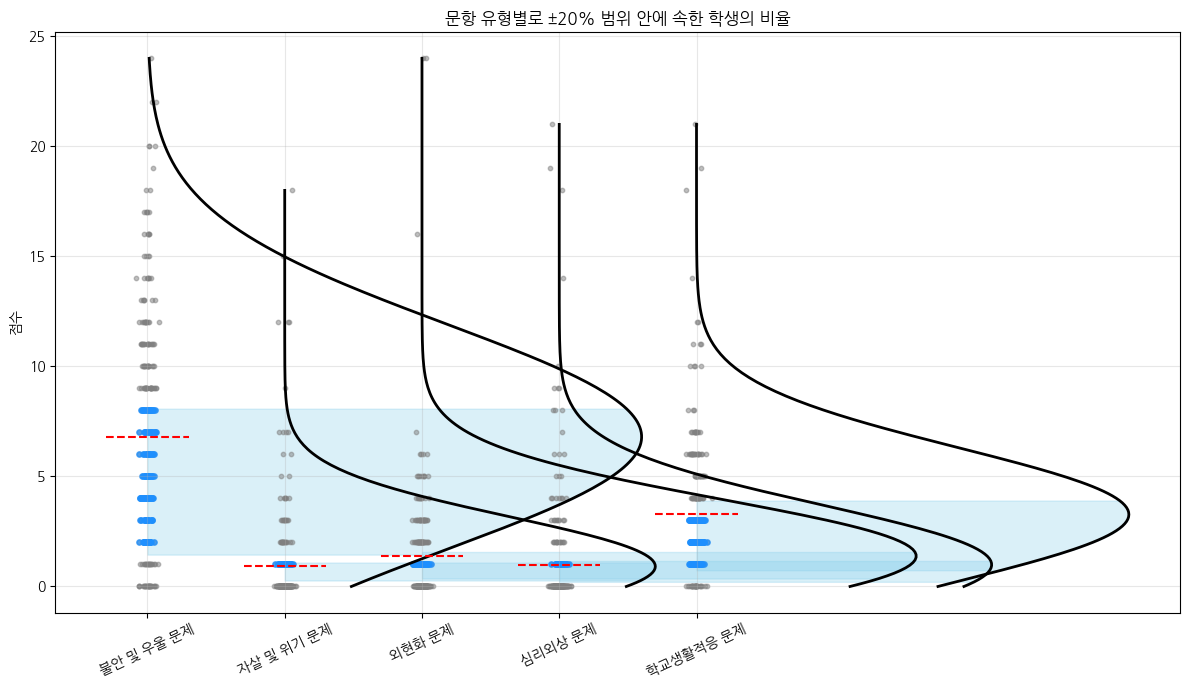

문항 유형별로 ±20% 범위 안에 속한 학생의 비율:

불안 및 우울 문제    47.00
자살 및 위기 문제    15.55
외현화 문제        22.26
심리외상 문제        8.48
학교생활적응 문제     53.36
dtype: float64
✅ Students within ±20% range for *all* problem types: 0 / 283 (0.00%)

Number of categories in range per student:
within_count
0    56
1    89
2    94
3    38
4     6
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_7248\3473400815.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["within_count"] = within_all.sum(axis=1)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Example dataframe
# subset = pd.read_csv("your_file.csv")

cols = ["불안 및 우울 문제", "자살 및 위기 문제", "외현화 문제", "심리외상 문제", "학교생활적응 문제"]

# 1️⃣ Compute mean and std
means = subset[cols].mean()
stds = subset[cols].std()

# 2️⃣ Define ±20% bounds (your original used 1.2 and 0.8)
lower = means * 0.2
upper = means * 1.2

# 3️⃣ Prepare figure
plt.figure(figsize=(12, 7))

for i, col in enumerate(cols):
    y = subset[col]
    mean = means[col]
    std = stds[col]
    x = np.linspace(y.min(), y.max(), 200)

    # Normal distribution PDF
    pdf = norm.pdf(x, mean, std)
    pdf_scaled = pdf / pdf.max() * (y.max() - y.min()) * \
        0.15  # rescale for display

    # Draw normal curve centered vertically around category
    plt.plot(i + pdf_scaled, x, color="black", lw=2)

    # Shade ±20% range
    plt.fill_betweenx(x, i, i + pdf_scaled, where=(x >= lower[col]) & (x <= upper[col]),
                      color="skyblue", alpha=0.3)

    # Scatter student scores (with horizontal jitter)
    jitter = np.random.normal(0, 0.03, len(y))
    plt.scatter(np.full_like(y, i) + jitter, y, alpha=0.5, color="gray", s=10)

    # Highlight within range
    within = (y >= lower[col]) & (y <= upper[col])
    plt.scatter(np.full_like(y[within], i) + jitter[within], y[within],
                color="dodgerblue", alpha=0.7, s=15)

    # Mark mean line
    plt.hlines(mean, i - 0.3, i + 0.3, colors="red", linestyles="--")

# 4️⃣ Formatting
plt.xticks(range(len(cols)), cols, rotation=25)
plt.ylabel("점수")
plt.title(
    "문항 유형별로 ±20% 범위 안에 속한 학생의 비율")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5️⃣ Compute percentages within range
percent_within = ((subset[cols] >= lower) & (
    subset[cols] <= upper)).mean() * 100
print("문항 유형별로 ±20% 범위 안에 속한 학생의 비율:\n")
print(percent_within.round(2))

within_all = (subset[cols] >= lower) & (subset[cols] <= upper)

# Count how many columns each student is within range for
subset["within_count"] = within_all.sum(axis=1)

# Count students who are within range for *all* categories
students_all_in_range = (subset["within_count"] == len(cols)).sum()
total_students = len(subset)
percentage_all_in_range = students_all_in_range / total_students * 100

print(
    f"✅ Students within ±20% range for *all* problem types: {students_all_in_range} / {total_students} ({percentage_all_in_range:.2f}%)")

# (Optional) View distribution of how many categories each student falls in range for
count_distribution = subset["within_count"].value_counts().sort_index()
print("\nNumber of categories in range per student:")
print(count_distribution)

In [7]:
import pandas as pd

df = pd.read_csv("./input/question_data.csv")

# Per-question mean (aligned to each row), check ±1, then "all within" per student
qmean = df.groupby("Question")["Answer"].transform("mean")
within = (df["Answer"].sub(qmean).abs() <= 1)
all_ok = within.groupby(df["student_id"]).all()

n, tot = all_ok.sum(), all_ok.size
print(f"✅ {n} / {tot} students ({n/tot*100:.2f}%) have all answers within ±1 of each question’s average.")

✅ 17 / 283 students (6.01%) have all answers within ±1 of each question’s average.


In [8]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv("./input/question_data.csv")

# --- config ---
k = 1.0  # number of sigmas (±kσ). Change to 2.0 for ±2σ, etc.
# -------------

# Per-question mean & std aligned to each row
q_stats = df.groupby("Question")["Answer"].agg(["mean", "std"])
df = df.join(q_stats, on="Question")

# Within ±kσ for each row (handle std==0: only exact-mean counts as within)
diff = (df["Answer"] - df["mean"]).abs()
within = np.where(df["std"].eq(0.0), diff.eq(0.0), diff <= k * df["std"])

# Count per student
per_student_counts = (
    pd.Series(within, index=df.index)
      .groupby(df["student_id"])
      .sum()
      .rename("n_within_pm_k_sigma")
)

# Also report how many questions each student answered (denominator) and the fraction
per_student_total = df.groupby("student_id")[
    "Answer"].size().rename("n_questions")
result = pd.concat([per_student_counts, per_student_total], axis=1)
result["fraction_within"] = result["n_within_pm_k_sigma"] / result["n_questions"]

print(result.sort_values("fraction_within", ascending=False))

            n_within_pm_k_sigma  n_questions  fraction_within
student_id                                                   
학생94                         36           36         1.000000
학생14                         35           36         0.972222
학생135                        35           36         0.972222
학생33                         35           36         0.972222
학생272                        35           36         0.972222
...                         ...          ...              ...
학생238                        11           36         0.305556
학생131                         8           36         0.222222
학생142                         2           36         0.055556
학생229                         0           36         0.000000
학생01                          0           36         0.000000

[283 rows x 3 columns]


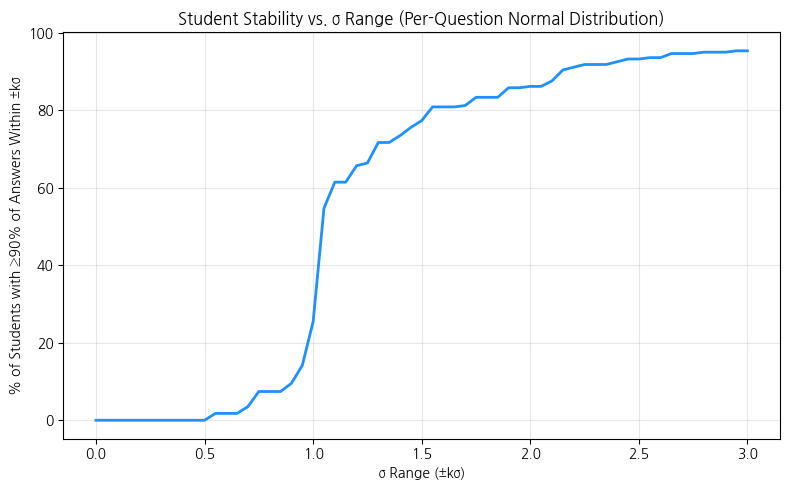

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load
df = pd.read_csv("./input/question_data.csv")

# ── compute per-question mean & std once ───────────────────────
q_stats = df.groupby("Question")["Answer"].agg(["mean", "std"])
df = df.join(q_stats, on="Question")

diff = (df["Answer"] - df["mean"]).abs()
std = df["std"]

# ── parameters ────────────────────────────────────────────────
threshold = 0.90     # 90% of questions within ±kσ
k_values = np.linspace(0, 3, 61)  # continuous 0 → 3 in 0.05 steps
n_students = df["student_id"].nunique()

student_percentages = []

for k in k_values:
    # Check within ±kσ (handle std=0)
    within = np.where(std.eq(0.0), diff.eq(0.0), diff <= k * std)
    frac = (
        pd.Series(within, index=df.index)
          .groupby(df["student_id"])
          .mean()
    )
    count_ge = (frac >= threshold).sum()
    pct = 100 * count_ge / n_students
    student_percentages.append(pct)

# ── Plot ───────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(k_values, student_percentages, color="dodgerblue", lw=2)
plt.xlabel("σ Range (±kσ)")
plt.ylabel("% of Students with ≥90% of Answers Within ±kσ")
plt.title("Student Stability vs. σ Range (Per-Question Normal Distribution)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()